# Steam Game Recommendation System
## Recommender Systems + Natural Language Processing

> *Find your next favourite game.* A content-based and hybrid recommendation engine for the Steam catalogue, built from game descriptions, user tags and review statistics.

| | |
|---|---|
| **Dataset** | Steam Games Dataset (`games.csv`): about 125k titles with descriptions, tags, genres, prices and review counts |
| **Recommender techniques** | Content-based filtering · Latent Semantic Analysis · quality-aware re-ranking · user-profile personalisation · semantic text search |
| **NLP techniques** | Text cleaning · stop-word handling · TF-IDF with uni/bi-grams · cosine similarity · truncated SVD (LSA) · keyword extraction |
| **Libraries** | pandas · NumPy · SciPy · scikit-learn · Matplotlib |
| **Runtime** | About 1.5 minutes end-to-end on a single CPU core in testing; the optional transformer step (7.8) adds roughly 10 to 20 minutes if enabled |

### Table of contents

1. Introduction
2. Setup and Configuration
3. Data Loading
4. Data Cleaning and Catalogue Construction
5. Exploratory Data Analysis
6. NLP Feature Engineering
7. Recommender Models
8. Offline Evaluation
9. Visualising the Game Embedding Space
10. Conclusions, Limitations and Future Work

---
## 1. Introduction

### 1.1 Problem statement

Steam lists well over 100,000 titles and hundreds more appear every month. Nobody can browse that much, so discovery depends on search, charts and recommendations. This notebook builds a recommender that answers three practical questions:

1. **"I loved game X. What else is like it?"** (single-title similarity)
2. **"Here are several games I like and dislike. What should I play next?"** (personalised recommendations)
3. **"I want something like …"** (free-text semantic search)

### 1.2 Approach

| Section | Recommender | Idea | Input |
|---|---|---|---|
| 7.2 | **Content-based (TF-IDF hybrid)** | Cosine similarity over description n-grams *and* user tags | one title |
| 7.3 | **Latent Semantic Analysis (LSA)** | Truncated SVD compresses the sparse TF-IDF space into dense "topic" vectors, so related words match | one title |
| 7.4 | **Quality-aware re-ranking** | Blend similarity with a Bayesian-average rating and popularity so obscure or poorly-rated games are demoted | any |
| 7.5 | **User-profile personalisation** | Average the vectors of liked games (minus disliked ones) into a taste profile | several titles |
| 7.6 | **Semantic text search** | Project a free-text query into the same vector space | free text |
| 7.7 | **Explainable recommendations** | Show the shared tags and keywords behind each suggestion | a pair of titles |
| 7.8 | *Optional* transformer embeddings | Dense sentence embeddings as a drop-in alternative | one title |

### 1.3 A note on the data

* `games.csv` is an **item catalogue**. It contains no per-user interactions (who played or rated what), so classic *collaborative filtering* cannot be trained from this file alone. The recommenders here are therefore **content-based and popularity-aware**. Section 10 explains how to add collaborative filtering when interaction data is available.
* The CSV header has **39 column names but every row has 40 values**: "Discount" and "DLC count" are merged into a single `DiscountDLC count` header. Loading it naively shifts every column by one. Section 3 fixes this.

---
## 2. Setup and Configuration

### 2.1 Requirements

```bash
pip install pandas numpy scipy scikit-learn matplotlib
pip install sentence-transformers   # optional, only for section 7.8
```

Place `games.csv` next to this notebook (or change `DATA_PATH` below).

### 2.2 Imports

In [1]:
import gc
import math
import re
import time
import warnings
from collections import Counter
from difflib import get_close_matches

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02", "#a6761d", "#666666"]

### 2.3 Configuration

All tunable settings live in one place. The defaults work well; change them to experiment.

In [2]:
# ------------------------------- data ---------------------------------
DATA_PATH = "games.csv"          # path to the Steam games CSV

# -------------------------- catalogue filters --------------------------
MIN_REVIEWS     = 20             # titles with fewer reviews are too noisy to recommend
REQUIRE_ENGLISH = True           # the NLP pipeline below is English-only
EXCLUDE_ADULT   = True           # drop adult-only titles (see section 4.3)

# --------------------------- NLP and models ----------------------------
MAX_DESC_CHARS  = 2000           # truncate very long descriptions
MAX_TAGS        = 10             # keep each game's 10 most-voted user tags
W_TEXT, W_TAGS  = 0.6, 0.4       # share of the similarity coming from text vs. tags
LSA_COMPONENTS  = 150            # dimensionality of the latent semantic space
BETA            = 0.25           # weight of "quality" when re-ranking (0 = similarity only)
TOP_N           = 10             # default length of a recommendation list
USE_TRANSFORMERS = False         # optional dense embeddings (section 7.8)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

---
## 3. Data Loading

The header has one name too few (see section 1.3), so we supply the 40 correct column names ourselves and tell pandas to replace the header row. We also load only the columns the recommender needs. This skips the very large `Screenshots` and `Movies` columns and cuts memory use and load time considerably.

In [3]:
COLUMNS = [
    "AppID", "Name", "Release date", "Estimated owners", "Peak CCU", "Required age", "Price",
    "Discount", "DLC count",                      # <- a single merged header in the raw file
    "About the game", "Supported languages", "Full audio languages", "Reviews", "Header image",
    "Website", "Support url", "Support email", "Windows", "Mac", "Linux", "Metacritic score",
    "Metacritic url", "User score", "Positive", "Negative", "Score rank", "Achievements",
    "Recommendations", "Notes", "Average playtime forever", "Average playtime two weeks",
    "Median playtime forever", "Median playtime two weeks", "Developers", "Publishers",
    "Categories", "Genres", "Tags", "Screenshots", "Movies",
]
assert len(COLUMNS) == 40

USECOLS = [
    "AppID", "Name", "Release date", "Estimated owners", "Peak CCU", "Required age", "Price",
    "About the game", "Supported languages", "Windows", "Mac", "Linux", "Metacritic score",
    "User score", "Positive", "Negative", "Recommendations", "Average playtime forever",
    "Median playtime forever", "Developers", "Publishers", "Categories", "Genres", "Tags",
]

t0 = time.time()
raw = pd.read_csv(DATA_PATH, header=0, names=COLUMNS, usecols=USECOLS)
print(f"Loaded {len(raw):,} rows x {raw.shape[1]} columns in {time.time() - t0:.0f}s")
display(raw[["AppID", "Name", "Release date", "Price", "Positive", "Negative", "Genres"]].head())

Loaded 130,100 rows x 24 columns in 4s


,AppID,Name,Release date,Price,Positive,Negative,Genres
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0.00,0,0,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",5.24,252,3,Adventure
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",4.99,21,3,Casual
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",8.99,0,0,"Casual,Indie,Simulation"
4,3631080,Maze Quest VR,"Apr 24, 2025",4.99,0,0,"Action,Early Access"


**Sanity check.** If the columns were still shifted, `Price` would contain text and `Positive` would not look like a review count.

In [4]:
print(f"Price range            : ${raw['Price'].min():.2f} to ${raw['Price'].max():.2f}  (dtype {raw['Price'].dtype})")
print(f"Positive reviews range : {raw['Positive'].min():,} to {raw['Positive'].max():,}  (dtype {raw['Positive'].dtype})")
print(f"Rows with a description: {(raw['About the game'].fillna('').str.len() > 0).mean():.1%}")
print(f"Rows with tags         : {(raw['Tags'].fillna('').str.len() > 0).mean():.1%}")

Price range            : $0.00 to $999.98  (dtype float64)
Positive reviews range : 0 to 7,642,084  (dtype int64)
Rows with a description: 93.3%
Rows with tags         : 66.2%


---
## 4. Data Cleaning and Catalogue Construction

### 4.1 Remove duplicates

Two rows are duplicates if they are identical in every column except `AppID`. If you padded the file with copied rows (for example to reach 130k+ rows for testing), this step removes the copies again so they cannot appear as "recommendations" for their own originals.

In [5]:
n_raw = len(raw)
content_cols = [c for c in raw.columns if c != "AppID"]
df = raw.drop_duplicates(subset=content_cols, keep="first").drop_duplicates(subset="AppID")
del raw
gc.collect()
print(f"Removed {n_raw - len(df):,} duplicate rows  ({n_raw:,} -> {len(df):,})")

Removed 4,253 duplicate rows  (130,100 -> 125,847)


### 4.2 Types and derived features

* missing text becomes an empty string;
* release dates are parsed into real dates (and a release year);
* `Estimated owners` (a range such as `"0 - 20000"`) becomes a numeric midpoint;
* review totals and the share of positive reviews are derived;
* comma-separated `Tags` and `Genres` become Python lists;
* titles that are not games (soundtracks, demos, playtests, software) and adult-only titles are flagged;
* a `name_key` (title + developer) is built so that several editions of one game can be merged later.

In [6]:
text_cols = ["Name", "About the game", "Supported languages", "Developers", "Publishers",
             "Categories", "Genres", "Tags"]
for c in text_cols:
    df[c] = df[c].fillna("").astype(str)
df["Name"] = df["Name"].str.strip()
df = df[df["Name"] != ""].copy()

# release date -> datetime / year
try:
    df["release_date"] = pd.to_datetime(df["Release date"], errors="coerce", format="mixed")
except (TypeError, ValueError):                       # pandas < 2.0
    df["release_date"] = pd.to_datetime(df["Release date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# "0 - 20000" -> midpoint
owners = df["Estimated owners"].fillna("").str.extract(r"(\d+)\s*-\s*(\d+)").astype(float)
df["owners_mid"] = owners.mean(axis=1)

# review statistics
df["n_reviews"] = df["Positive"] + df["Negative"]
df["pos_ratio"] = df["Positive"] / df["n_reviews"].where(df["n_reviews"] > 0)

# list-valued columns
df["tag_list"]   = df["Tags"].map(lambda s: [t.strip() for t in s.split(",") if t.strip()])
df["genre_list"] = df["Genres"].map(lambda s: [g.strip() for g in s.split(",") if g.strip()])

# adult-only content: Steam's own adult genres, or an explicit hentai / NSFW tag among the top tags.
# (Mainstream mature games such as The Witcher 3 carry a user-voted "Nudity" tag but are not adult-only,
#  so that tag alone is deliberately NOT used.)
top_tags = df["Tags"].map(lambda s: ",".join(s.split(",")[:MAX_TAGS]))
df["is_adult"] = (df["Genres"].str.contains(r"sexual content|nudity", case=False, regex=True)
                  | top_tags.str.contains(r"hentai|nsfw", case=False, regex=True))

# things that are not games: soundtracks, demos, playtests, and software / utilities
SOFTWARE_GENRES = (r"utilities|animation & modeling|audio production|design & illustration|photo editing|"
                   r"software training|video production|web publishing|game development|accounting")
df["is_non_game"] = (
    df["Name"].str.contains(r"\b(?:soundtrack|original sound ?track|ost|artbook|playtest|demo|wallpapers?)\b",
                            case=False, regex=True)
    | df["Genres"].str.contains(SOFTWARE_GENRES, case=False, regex=True))

# key used to collapse several editions / AppIDs of the same title into one catalogue entry
df["name_key"] = df["Name"].str.lower() + "|" + df["Developers"].str.lower()

print(f"{len(df):,} titles | {df['is_adult'].sum():,} adult-only | {df['is_non_game'].sum():,} soundtracks/demos/playtests/software")

125,846 titles | 1,005 adult-only | 9,934 soundtracks/demos/playtests/software


### 4.3 Build the recommendation catalogue

Not every title is a sensible candidate. A game with three reviews has noisy statistics, a title with neither a description nor tags gives the models nothing to work with (a few big games have an empty description in this dump; they are kept and rely on their tags), and a soundtrack or a utility is not a game. Some games also appear under several AppIDs (editions, test servers), which would otherwise show up as repeated recommendations, so we keep only the most-reviewed one. We apply every filter below and report how many titles survive each step.

> **Adult-only filter.** It uses Steam's own adult-content genres plus explicit *Hentai*/*NSFW* tags among a game's top tags. It deliberately does **not** use the user-voted *Nudity* tag alone, because that tag also sits on mainstream mature games such as *The Witcher 3* or *Baldur's Gate 3*. The filter is a heuristic, so a few borderline titles can slip through. Set `EXCLUDE_ADULT = False` to disable it.

In [7]:
steps = [
    ("All de-duplicated titles",                  pd.Series(True, index=df.index)),
    (f"At least {MIN_REVIEWS} reviews",           df["n_reviews"] >= MIN_REVIEWS),
    ("Has a description (>= 50 chars) or tags",   (df["About the game"].str.len() >= 50) | (df["Tags"] != "")),
    ("A game (not soundtrack / demo / playtest / software)", ~df["is_non_game"]),
    ("Supports English" if REQUIRE_ENGLISH else "(English filter off)",
        df["Supported languages"].str.contains("English", case=False) if REQUIRE_ENGLISH else pd.Series(True, index=df.index)),
    ("Not adult-only" if EXCLUDE_ADULT else "(adult filter off)",
        ~df["is_adult"] if EXCLUDE_ADULT else pd.Series(True, index=df.index)),
]

mask = pd.Series(True, index=df.index)
funnel = []
for label, condition in steps:
    mask &= condition
    funnel.append((label, int(mask.sum())))

# several AppIDs can share one title (editions, test servers, regional versions): keep the most-reviewed one
best_edition = df[mask].sort_values("n_reviews", ascending=False).drop_duplicates("name_key").index
mask &= df.index.isin(best_edition)
funnel.append(("One entry per title (most-reviewed edition)", int(mask.sum())))

display(pd.DataFrame(funnel, columns=["filter (cumulative)", "titles remaining"]))

catalog = df[mask].reset_index(drop=True)
print(f"\nRecommendation catalogue: {len(catalog):,} games")

,filter (cumulative),titles remaining
0,All de-duplicated titles,125846
1,At least 20 reviews,44568
2,Has a description (>= 50 chars) or tags,44568
3,A game (not soundtrack / demo / playtest / software),43910
4,Supports English,42383
5,Not adult-only,41595
6,One entry per title (most-reviewed edition),41513



Recommendation catalogue: 41,513 games


---
## 5. Exploratory Data Analysis

Before modelling, we look at what the catalogue contains. The goal is to understand the shape of the data, especially the heavy skew in popularity, because it affects how we design and evaluate the recommender.

### 5.1 Catalogue summary

In [8]:
genre_counts = Counter(g for gl in catalog["genre_list"] for g in gl)
tag_counts   = Counter(t for tl in catalog["tag_list"] for t in tl[:MAX_TAGS])

summary = pd.DataFrame({
    "value": {
        "Titles (de-duplicated)":              f"{len(df):,}",
        "Titles in recommendation catalogue":  f"{len(catalog):,}",
        "Median reviews per catalogue title":  f"{catalog['n_reviews'].median():,.0f}",
        "Mean reviews per catalogue title":    f"{catalog['n_reviews'].mean():,.0f}",
        "Median share of positive reviews":    f"{catalog['pos_ratio'].median():.1%}",
        "Free-to-play share":                  f"{(catalog['Price'] == 0).mean():.1%}",
        "Median price of paid games (USD)":    f"${catalog.loc[catalog['Price'] > 0, 'Price'].median():.2f}",
        "Distinct genres":                     f"{len(genre_counts)}",
        "Distinct tags (top-10 per game)":     f"{len(tag_counts)}",
    }
})
display(summary)

,value
Titles (de-duplicated),"125,846"
Titles in recommendation catalogue,"41,513"
Median reviews per catalogue title,104
Mean reviews per catalogue title,"3,437"
Median share of positive reviews,81.2%
Free-to-play share,13.0%
Median price of paid games (USD),$3.89
Distinct genres,16
Distinct tags (top-10 per game),446


### 5.2 Releases over time

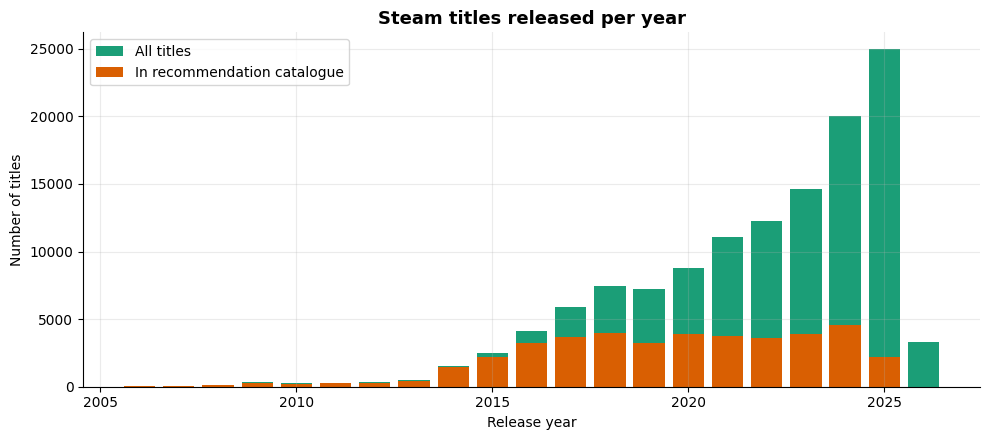

In [9]:
yearly_all = df["release_year"].value_counts().sort_index()
yearly_cat = catalog["release_year"].value_counts().sort_index()
last_year = int(df["release_year"].max())
years = [y for y in range(2006, last_year + 1)]

fig, ax = plt.subplots()
ax.bar(years, [yearly_all.get(y, 0) for y in years], color=PALETTE[0], label="All titles")
ax.bar(years, [yearly_cat.get(y, 0) for y in years], color=PALETTE[1], label="In recommendation catalogue")
ax.set_title("Steam titles released per year")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of titles")
ax.legend()
plt.tight_layout()
plt.show()

**What the data shows.** Releases have grown roughly ten-fold in a decade, from about 2,500 titles in 2015 to about 25,000 in 2025 (2026 is a partial year in this snapshot). The recommendation catalogue grows far more slowly (3,914 titles from 2020, 3,900 from 2023, 4,569 from 2024), so it covers 87% of 2015 releases but only 23% of 2024 and 9% of 2025 releases. Recent games have simply not collected `MIN_REVIEWS` reviews yet, and none of the 2026 titles qualify. This is a built-in **recency gap**: the recommender can only suggest games that already have a review track record.

### 5.3 Price and review distributions

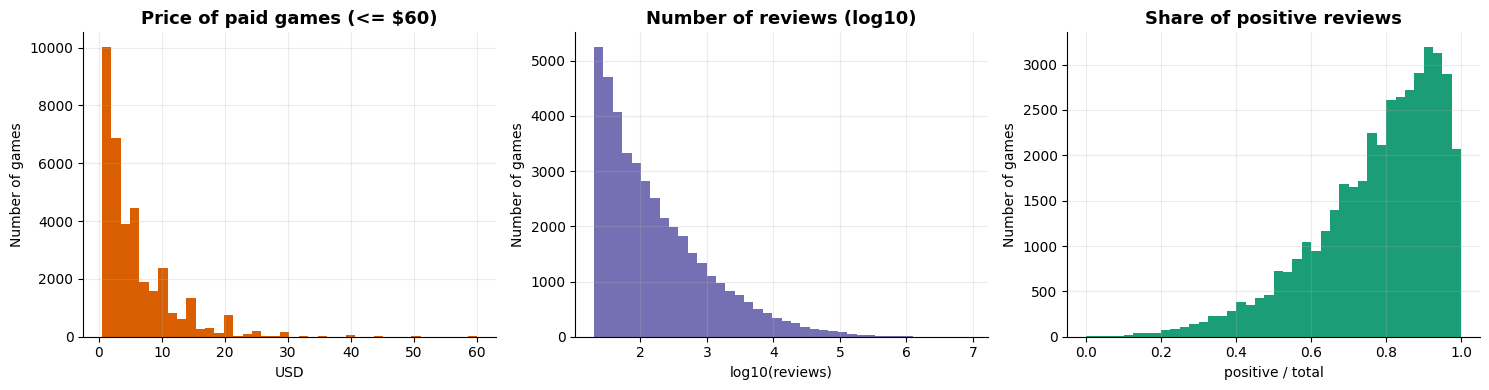

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

paid = catalog.loc[(catalog["Price"] > 0) & (catalog["Price"] <= 60), "Price"]
axes[0].hist(paid, bins=40, color=PALETTE[1])
axes[0].set_title("Price of paid games (<= $60)")
axes[0].set_xlabel("USD")

axes[1].hist(np.log10(catalog["n_reviews"].clip(lower=1)), bins=40, color=PALETTE[2])
axes[1].set_title("Number of reviews (log10)")
axes[1].set_xlabel("log10(reviews)")

axes[2].hist(catalog["pos_ratio"].dropna(), bins=40, color=PALETTE[0])
axes[2].set_title("Share of positive reviews")
axes[2].set_xlabel("positive / total")

for ax in axes:
    ax.set_ylabel("Number of games")
plt.tight_layout()
plt.show()

**What the data shows.** Prices are low: 86% of paid catalogue games cost $10 or less and 97% cost $20 or less. Popularity is extremely skewed: the median game has about 100 reviews, 84% have fewer than 1,000, only 3.9% have 10,000 or more, and the top 1% of games hold roughly two-thirds (66%) of all reviews. Ratings are left-skewed: 72% of games are at least 70% positive and 27% at least 90%.

Two consequences for the recommender. Raw popularity would swamp everything and never surface the long tail. And a raw positive ratio is unreliable for games with few reviews, which motivates the Bayesian-average rating in section 7.4.

### 5.4 Most common genres and tags

Genres are Steam's official categories. Tags are user-voted descriptors and are much richer (for example "Roguelike", "Cozy", "Souls-like"). We use the 10 most-voted tags per game.

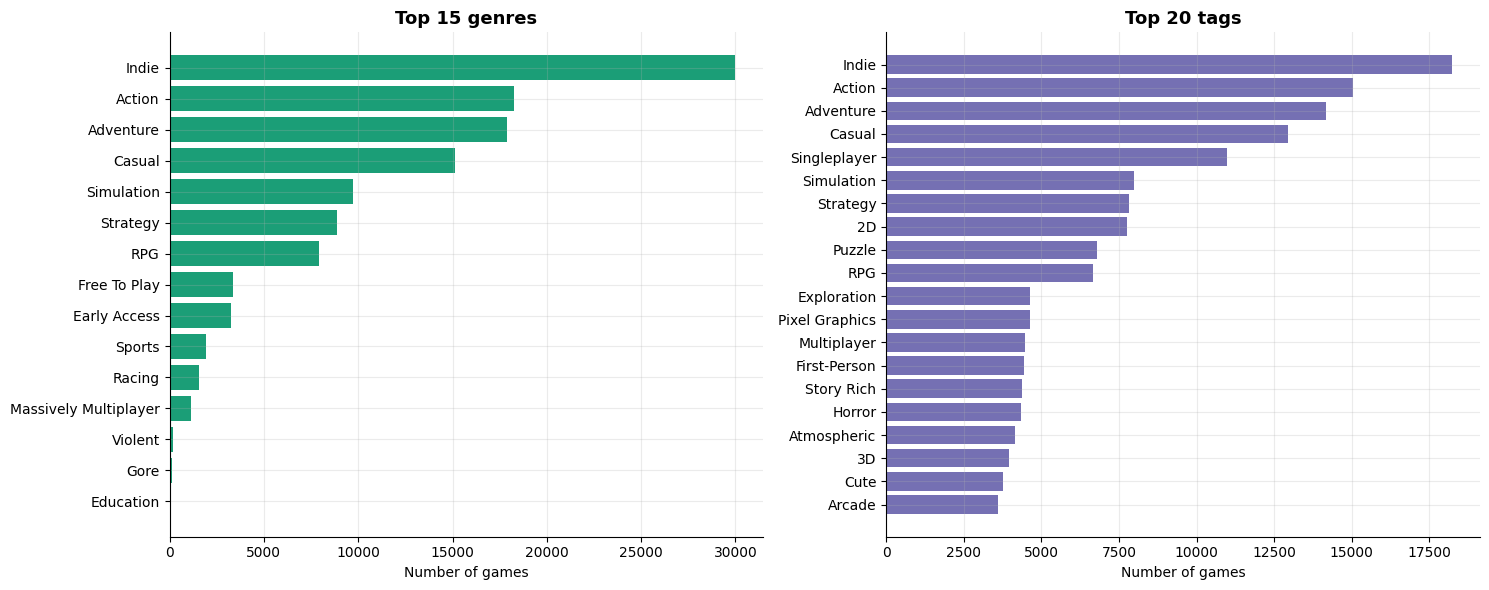

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, counts, title, color, k in [
    (axes[0], genre_counts, "Top 15 genres", PALETTE[0], 15),
    (axes[1], tag_counts,   "Top 20 tags",   PALETTE[2], 20),
]:
    items = counts.most_common(k)[::-1]
    ax.barh([name for name, _ in items], [n for _, n in items], color=color)
    ax.set_title(title)
    ax.set_xlabel("Number of games")
plt.tight_layout()
plt.show()

**What the data shows.** Indie (72% of the catalogue), Action (44%) and Adventure (43%) dominate, and most games carry several genres, so genres overlap heavily. There are only 16 distinct genres but 446 distinct tags among the top-10 lists, so tags (for example *Pixel Graphics*, *Story Rich*, *Exploration*) describe games far more finely. That is why the model uses tags as a feature, while the coarse official genres are kept aside as an independent yardstick for evaluation in section 8.

### 5.5 Description length and platform support

Description length matters for NLP: very short texts carry little signal, which is why a minimum length was part of the catalogue filter.

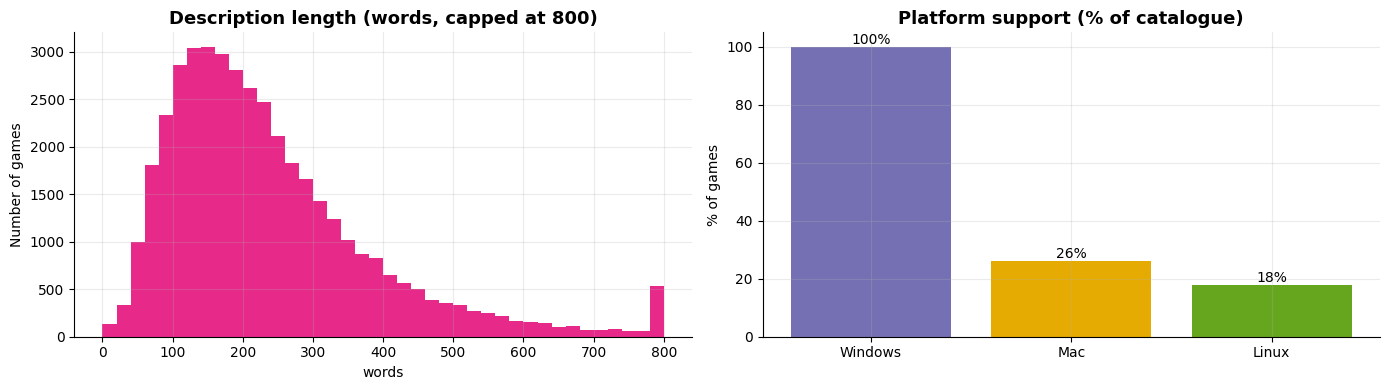

In [12]:
catalog["desc_words"] = catalog["About the game"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(catalog["desc_words"].clip(upper=800), bins=40, color=PALETTE[3])
axes[0].set_title("Description length (words, capped at 800)")
axes[0].set_xlabel("words")
axes[0].set_ylabel("Number of games")

share = catalog[["Windows", "Mac", "Linux"]].mean() * 100
axes[1].bar(share.index, share.values, color=[PALETTE[2], PALETTE[5], PALETTE[4]])
axes[1].set_title("Platform support (% of catalogue)")
axes[1].set_ylabel("% of games")
for i, v in enumerate(share.values):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha="center")
plt.tight_layout()
plt.show()

**What the data shows.** The median description has about 200 words (10th to 90th percentile: 88 to 429), which is enough text for TF-IDF to work with. Windows support is universal (100% of the catalogue), with Mac at 26% and Linux at 18%, so platform carries almost no recommendation signal and is not used as a feature.

---
## 6. NLP Feature Engineering

A recommender needs a numerical representation of every game. We build two complementary views:

| View | Source | Why |
|---|---|---|
| **Text** | the "About the game" description | captures themes, mechanics and tone in the developer's own words |
| **Tags** | the top-10 user-voted tags | a compact, high-precision vocabulary ("Open World", "Turn-Based") |

### 6.1 Text preprocessing

Raw Steam descriptions contain HTML, URLs, entities and marketing boilerplate. Our cleaning pipeline:

1. strip HTML tags, entities and URLs;
2. lower-case and keep letters only;
3. remove stop words, using scikit-learn's English list plus **domain stop words** ("game", "players", "features", …) that appear everywhere and carry no signal;
4. keep a few words scikit-learn normally drops but which matter here, such as *first* (as in "first-person shooter") and *top*, *back* and *system*.

Stop-word removal is applied inside the vectoriser so that n-grams are formed from the remaining words.

In [13]:
HTML_TAG_RE    = re.compile(r"<[^>]+>")
HTML_ENTITY_RE = re.compile(r"&[a-z]+;|&#\d+;")
URL_RE         = re.compile(r"https?://\S+|www\.\S+")
NON_ALPHA_RE   = re.compile(r"[^a-z\s]")
WHITESPACE_RE  = re.compile(r"\s+")

DOMAIN_STOPWORDS = {
    "game", "games", "play", "playing", "played", "player", "players", "feature", "features",
    "featuring", "steam", "new", "will", "can", "get", "gets", "make", "makes", "use", "uses",
    "also", "just", "one", "two", "way", "ways", "time", "every", "even", "much", "many", "like",
    "take", "need", "well", "help", "become", "enjoy", "experience",
}
KEEP_WORDS = {"first", "fire", "system", "back", "top", "front", "full", "side", "bottom"}
STOP_WORDS = sorted((ENGLISH_STOP_WORDS - KEEP_WORDS) | DOMAIN_STOPWORDS)


def clean_text(text: str) -> str:
    """Strip markup/URLs, lower-case, keep letters only."""
    text = HTML_TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = HTML_ENTITY_RE.sub(" ", text.lower())
    text = NON_ALPHA_RE.sub(" ", text)
    return WHITESPACE_RE.sub(" ", text).strip()


# a quick before / after on the most-reviewed game
example = catalog[catalog["About the game"].str.len() > 0].nlargest(1, "n_reviews").iloc[0]
snippet = example["About the game"][:260]
print("GAME :", example["Name"])
print("RAW  :", snippet.replace("\n", " "))
print("CLEAN:", clean_text(snippet))

GAME : Counter-Strike 2
RAW  : For over two decades, Counter-Strike has offered an elite competitive experience, one shaped by millions of players from across the globe. And now the next chapter in the CS story is about to begin. This is Counter-Strike 2. A free upgrade to CS:GO, Counter-St
CLEAN: for over two decades counter strike has offered an elite competitive experience one shaped by millions of players from across the globe and now the next chapter in the cs story is about to begin this is counter strike a free upgrade to cs go counter st


In [14]:
t0 = time.time()
catalog["text_clean"] = catalog["About the game"].str.slice(0, MAX_DESC_CHARS).map(clean_text)
print(f"Cleaned {len(catalog):,} descriptions in {time.time() - t0:.0f}s")
print(f"Average length after cleaning: {catalog['text_clean'].str.split().str.len().mean():.0f} words")

Cleaned 41,513 descriptions in 3s
Average length after cleaning: 209 words


### 6.2 TF-IDF text vectors

**TF-IDF** (term frequency × inverse document frequency) scores how characteristic a term is for a document: frequent in that description, but rare across the catalogue. Choices made here:

* **uni- and bi-grams** so that phrases like *open world*, *turn based* and *first person* become single features;
* `min_df=5` and `max_df=0.4` drop typos and ubiquitous terms;
* `sublinear_tf=True` uses 1 + log(tf), so a word repeated 20 times does not dominate;
* each vector is **L2-normalised**, so the dot product of two vectors *is* their cosine similarity.

In [15]:
t0 = time.time()
tfidf_text = TfidfVectorizer(
    stop_words=STOP_WORDS,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.4,
    max_features=120_000,
    sublinear_tf=True,
    dtype=np.float32,
)
X_text = tfidf_text.fit_transform(catalog["text_clean"])
terms = np.asarray(tfidf_text.get_feature_names_out())

density = X_text.nnz / (X_text.shape[0] * X_text.shape[1])
print(f"Text matrix: {X_text.shape[0]:,} games x {X_text.shape[1]:,} terms  "
      f"(density {density:.3%}, {time.time() - t0:.0f}s)")

Text matrix: 41,513 games x 120,000 terms  (density 0.094%, 16s)


### 6.3 Keyword extraction

A useful sanity check is to read off each game's highest-weighted terms. If the vectors are sensible, these should read like a summary of the game.

In [16]:
def top_terms(row_idx, k=8):
    """Highest-weighted TF-IDF terms of one game."""
    row = X_text[row_idx]
    order = np.argsort(row.data)[::-1][:k]
    return terms[row.indices[order]].tolist()


has_text = catalog["text_clean"].str.len() > 0
for i, r in catalog[has_text].nlargest(6, "n_reviews").iterrows():
    print(f"{r['Name']:<34} {', '.join(top_terms(i))}")

Counter-Strike 2                   counter strike, cs, counter, strike, workshop tools, upgraded, free upgrade, smoke grenades
PUBG: BATTLEGROUNDS                hinges, drop, risk, loot, drop different, selection maps, victory hinges, custom lobby
Dota 2                             dota, heroes, hero multiple, gameplay heroes, join first, free competitive, items meet, world inhabit
Grand Theft Auto V Legacy          grand theft, theft auto, theft, rockstar, auto, grand, santos, world los
Terraria                           terraria, worlds free, journey destination, completely control, construct city, monumental task, city house, world fingertips
Tom Clancy's Rainbow Six® Siege X  gather intel, siege, outplay, operators, intel, dual, advantage turn, tactical


### 6.4 What distinguishes each genre?

We compare the average TF-IDF vector of each genre with the catalogue-wide average. The terms with the largest lift are the words that most characterise that genre, a quick check that the text carries real genre signal even though genres were never given to the model.

In [17]:
overall_mean = np.asarray(X_text.mean(axis=0)).ravel()
rows = []
for genre, _ in genre_counts.most_common(10):
    idx = np.flatnonzero(catalog["genre_list"].map(lambda gl: genre in gl).to_numpy())
    lift = np.asarray(X_text[idx].mean(axis=0)).ravel() - overall_mean
    rows.append((genre, len(idx), ", ".join(terms[np.argsort(lift)[::-1][:10]])))

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(rows, columns=["genre", "games", "most distinctive terms (TF-IDF lift)"]))

,genre,games,most distinctive terms (TF-IDF lift)
0,Indie,29984,"levels, puzzle, puzzles, horror, level, platformer, different, soundtrack, simple, achievements"
1,Action,18244,"weapons, action, enemies, shooter, fight, bosses, combat, weapon, fast, enemy"
2,Adventure,17890,"adventure, story, explore, puzzles, solve, horror, secrets, mysterious, journey, dark"
3,Casual,15155,"puzzle, levels, relaxing, fun, music, achievements, simple, level, casual, beautiful"
4,Simulation,9720,"simulator, simulation, build, realistic, manage, real, customers, management, create, resources"
5,Strategy,8879,"strategy, build, units, tactical, turn, resources, turn based, cards, strategic, battle"
6,RPG,7919,"rpg, combat, monsters, dungeons, character, turn based, dungeon, quests, system, skills"
7,Free To Play,3347,"free, pvp, team, project, vr, multiplayer, online, friends, community, short"
8,Early Access,3257,"early access, early, build, access, multiplayer, survival, weapons, resources, create, development"
9,Sports,1949,"racing, ball, football, race, team, online, sports, multiplayer, teams, mode"


### 6.5 Tag vectors

Each tag becomes one token (multi-word tags are joined with underscores, so "Open World" becomes `open_world`) and the tag lists are TF-IDF weighted. Rare tags such as `souls-like` therefore count for more than ubiquitous ones such as `singleplayer`.

In [18]:
def tags_to_doc(tags):
    return " ".join(t.lower().replace(" ", "_") for t in tags[:MAX_TAGS])


catalog["tag_doc"] = catalog["tag_list"].map(tags_to_doc)
tfidf_tags = TfidfVectorizer(token_pattern=r"\S+", min_df=3, sublinear_tf=True, dtype=np.float32)
X_tags = tfidf_tags.fit_transform(catalog["tag_doc"])
print(f"Tag matrix: {X_tags.shape[0]:,} games x {X_tags.shape[1]:,} tags")
print("Games without any tags:", int((X_tags.getnnz(axis=1) == 0).sum()))

Tag matrix: 41,513 games x 444 tags
Games without any tags: 1


### 6.6 Hybrid feature matrix

We concatenate the two L2-normalised blocks, scaling each by the square root of its weight, and normalise again. The cosine similarity of two hybrid vectors is then exactly a **weighted average of their text similarity and their tag similarity**:

$$\text{sim}(a,b) \;=\; W_{\text{text}}\cdot\cos(\text{text}_a,\text{text}_b) \;+\; W_{\text{tags}}\cdot\cos(\text{tags}_a,\text{tags}_b)$$

`W_TEXT` and `W_TAGS` (section 2.3) control the blend.

In [19]:
X_hybrid = normalize(
    sp.hstack([math.sqrt(W_TEXT) * X_text, math.sqrt(W_TAGS) * X_tags], format="csr")
).astype(np.float32)

feature_names = np.concatenate([terms, ["tag:" + t for t in tfidf_tags.get_feature_names_out()]])
print(f"Hybrid matrix: {X_hybrid.shape[0]:,} x {X_hybrid.shape[1]:,}  ({X_hybrid.data.nbytes / 1e6:.0f} MB of values)")

Hybrid matrix: 41,513 x 120,444  (20 MB of values)


---
## 7. Recommender Models

### 7.1 Shared utilities

Small helpers used by every recommender: title lookup (exact, then substring, then fuzzy), cosine scoring, top-k selection and result formatting.

In [20]:
names_lower_s = catalog["Name"].str.lower()
names_lower = names_lower_s.to_numpy()
n_reviews_arr = catalog["n_reviews"].to_numpy()


def find_game(title: str, verbose: bool = True) -> int:
    """Row position of a game in the catalogue: exact -> substring -> fuzzy match.
    If several games match, the most-reviewed one wins. Non-exact matches are announced."""
    t = title.strip().lower()
    how = "exactly"
    hits = np.flatnonzero(names_lower == t)
    if len(hits) == 0:
        how = "as a substring"
        hits = np.flatnonzero(names_lower_s.str.contains(t, regex=False).to_numpy())
    if len(hits) == 0:
        how = "by fuzzy match"
        close = get_close_matches(t, names_lower.tolist(), n=1, cutoff=0.75)
        if not close:
            raise KeyError(f"No game found matching '{title}'. It may have been removed by a catalogue "
                           f"filter (section 4.3), e.g. too few reviews.")
        hits = np.flatnonzero(names_lower == close[0])
    i = int(hits[np.argmax(n_reviews_arr[hits])])
    if verbose and how != "exactly":
        print(f"[note] '{title}' matched {how}: using '{catalog.at[i, 'Name']}'")
    return i


def cosine_scores(matrix, query_vec):
    """Cosine similarity of every catalogue row to one query vector (all rows are L2-normalised)."""
    if sp.issparse(matrix):
        q = query_vec if sp.issparse(query_vec) else sp.csr_matrix(np.asarray(query_vec).reshape(1, -1))
        return (matrix @ q.T).toarray().ravel()
    return matrix @ np.asarray(query_vec).ravel()


def top_k_indices(scores, k, exclude=()):
    """Indices of the k highest scores (descending), skipping excluded positions."""
    scores = np.array(scores, dtype=np.float64, copy=True)
    if len(exclude):
        scores[np.asarray(list(exclude), dtype=int)] = -np.inf
    k = min(k, len(scores))
    part = np.argpartition(-scores, k - 1)[:k]
    return part[np.argsort(-scores[part])]


def format_results(idx, final=None, sims=None):
    """Tidy table for a list of catalogue positions."""
    out = catalog.iloc[idx][["Name", "Genres", "Price", "release_year", "pos_ratio", "n_reviews"]].copy()
    out["Genres"] = out["Genres"].str.replace(",", ", ").str.slice(0, 45)
    out["pos_ratio"] = (out["pos_ratio"] * 100).round(0)
    out["release_year"] = out["release_year"].astype("Int64")
    out.columns = ["Game", "Genres", "Price ($)", "Year", "Positive %", "Reviews"]
    if sims is not None:
        out["Similarity"] = np.round(sims, 3)
    if final is not None:
        out["Final score"] = np.round(final, 3)
    out.insert(0, "#", range(1, len(out) + 1))
    return out.reset_index(drop=True)


print("Utilities ready. Example lookup ->", catalog.at[find_game("stardew valley"), "Name"])

Utilities ready. Example lookup -> Stardew Valley


### 7.2 Content-based recommender (TF-IDF hybrid)

The simplest strong baseline: represent the query game as a vector, compute its cosine similarity to every other game, and return the nearest neighbours. Games with the same name as the query (alternate editions) are excluded.

In [21]:
def recommend_similar(title, n=TOP_N, matrix=None, show=True):
    """Games most similar to `title` by cosine similarity on `matrix` (default: hybrid TF-IDF)."""
    matrix = X_hybrid if matrix is None else matrix
    q = find_game(title)
    sims = cosine_scores(matrix, matrix[q])
    same_name = np.flatnonzero(names_lower == names_lower[q])
    idx = top_k_indices(sims, n, exclude=same_name)
    if show:
        print(f"Because you liked: {catalog.at[q, 'Name']}   [{catalog.at[q, 'Genres']}]")
    return format_results(idx, sims=sims[idx])


display(recommend_similar("Stardew Valley"))
display(recommend_similar("Counter-Strike"))
display(recommend_similar("The Witcher 3: Wild Hunt"))

Because you liked: Stardew Valley   [Indie,RPG,Simulation]


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity
0,1,Cornucopia®,"Adventure, Casual, Indie, RPG, Simulation, Ea",18.74,2023,89.0,545,0.434
1,2,Circadian City,"Adventure, Indie, RPG, Simulation, Strategy,",11.99,2020,60.0,163,0.409
2,3,Coral Island,"Adventure, Casual, Indie, RPG, Simulation, St",17.99,2023,88.0,21728,0.394
3,4,Seeds of Calamity,"Adventure, Casual, Indie, RPG, Simulation, Ea",8.99,2025,94.0,103,0.391
4,5,Garden Buddies,"Adventure, Casual, Indie, RPG",14.99,2023,72.0,81,0.367
5,6,Melting Hearts: Our Love Will Grow 2,"Adventure, Indie, RPG, Simulation",0.00,2016,57.0,68,0.348
6,7,Littlewood,"Adventure, Casual, Indie, RPG, Simulation",7.49,2020,93.0,6679,0.344
7,8,Garden Paws,"Adventure, Indie, RPG, Simulation",14.99,2018,91.0,2450,0.343
8,9,Russian Village Simulator on Mars,"Action, Adventure, Casual, Indie, RPG, Simula",7.99,2025,80.0,30,0.337
9,10,Dinkum,"Adventure, Casual, Indie, RPG, Simulation",15.99,2025,92.0,24584,0.336


Because you liked: Counter-Strike   [Action]


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity
0,1,Counter-Strike: Condition Zero,Action,1.99,2004,91.0,26558,0.376
1,2,Team Fortress Classic,Action,1.24,1999,87.0,8738,0.325
2,3,Counter-Strike: Source,Action,1.99,2004,96.0,182234,0.325
3,4,Tom Clancy's Rainbow Six® Vegas,Action,2.49,2008,80.0,1491,0.301
4,5,Quake III Arena,Action,5.99,2007,96.0,3753,0.297
5,6,Counter-Strike 2,"Action, Free To Play",0.00,2012,87.0,8815087,0.295
6,7,Task Force,"Action, Indie, Strategy, Early Access",0.00,2022,73.0,409,0.287
7,8,Tom Clancy's Rainbow Six® 3 Gold,Action,2.49,2008,92.0,1944,0.286
8,9,Intruder,Early Access,9.99,2019,90.0,6583,0.286
9,10,Z.A.R.,Action,1.19,2015,63.0,91,0.278


Because you liked: The Witcher 3: Wild Hunt   [RPG]


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity
0,1,GreedFall II: The Dying World,"Action, Adventure, RPG, Early Access",31.99,2024,56.0,473,0.597
1,2,Cyberpunk 2077,RPG,20.99,2020,84.0,844921,0.593
2,3,The Witcher: Enhanced Edition Director's Cut,"Action, RPG",1.49,2008,89.0,82704,0.528
3,4,The Witcher 2: Assassins of Kings Enhanced Edition,RPG,2.99,2012,90.0,87064,0.491
4,5,AKIBA'S TRIP: Undead ＆ Undressed,"Action, Adventure, Casual, RPG",7.99,2015,85.0,3347,0.404
5,6,Katagiri-san is very cold,Adventure,2.79,2024,88.0,59,0.370
6,7,Everlasting Summer,"Adventure, Casual, Indie, Free To Play",0.00,2014,95.0,75514,0.370
7,8,Dragon Age: Origins - Ultimate Edition,RPG,2.99,2010,87.0,28412,0.362
8,9,Fable - The Lost Chapters,"Action, Adventure, RPG",3.29,2011,92.0,7738,0.362
9,10,Dragon Age™ Inquisition,"Action, Adventure, RPG, Strategy",3.99,2020,75.0,19595,0.359


### 7.3 Latent Semantic Analysis (LSA)

TF-IDF is *lexical*: two descriptions only match if they share the same words, and "scary" will not match "terrifying". **Latent Semantic Analysis** applies truncated SVD to the TF-IDF matrix, projecting every game into a dense space of `LSA_COMPONENTS` latent "topics". Words that tend to co-occur load onto the same topics, so games can be similar *without* sharing exact vocabulary. The dense vectors are also much cheaper to store and compare.

In [22]:
t0 = time.time()
svd = TruncatedSVD(n_components=LSA_COMPONENTS, random_state=RANDOM_STATE)
Z = normalize(svd.fit_transform(X_hybrid)).astype(np.float32)
print(f"LSA embedding: {Z.shape}  | variance retained {svd.explained_variance_ratio_.sum():.1%}  | {time.time() - t0:.0f}s")

# What do some latent topics look like? (strongest tags | strongest description terms)
n_text = len(terms)
tag_names = np.asarray(tfidf_tags.get_feature_names_out())
for k in [1, 4, 8, 12, 16, 20]:
    comp = svd.components_[k]
    if comp[np.argmax(np.abs(comp))] < 0:           # SVD signs are arbitrary: show the dominant pole
        comp = -comp
    top_tags = tag_names[np.argsort(comp[n_text:])[::-1][:4]]
    top_terms_ = terms[np.argsort(comp[:n_text])[::-1][:6]]
    print(f"topic {k:>2}:  {', '.join(top_tags):<46}| {', '.join(top_terms_)}")

LSA embedding: (41513, 150)  | variance retained 30.9%  | 8s
topic  1:  horror, puzzle, adventure, story_rich         | puzzles, horror, story, solve, adventure, puzzle
topic  4:  action, indie, vr, horror                     | vr, horror, first person, person, shooter, virtual
topic  8:  strategy, horror, psychological_horror, simulation| horror, endings, novel, visual novel, units, strategy
topic 12:  free_to_play, survival, point_&_click, building| build, resources, survival, weapons, space, survive
topic 16:  pixel_graphics, retro, rpg, fps               | rpg, pixel, retro, hidden object, classic, horror
topic 20:  violent, gore, colorful, cute                 | racing, cats, choices, car, click, race


Comparing sparse TF-IDF neighbours with LSA neighbours for the same query shows how the two spaces differ:

In [23]:
def compare_models(title, n=8):
    a = recommend_similar(title, n, X_hybrid, show=False)["Game"].to_numpy()
    b = recommend_similar(title, n, Z, show=False)["Game"].to_numpy()
    print(f"Query: {catalog.at[find_game(title), 'Name']}   |   overlap between the two lists: {len(set(a) & set(b))}/{n}")
    return pd.DataFrame({"TF-IDF hybrid (sparse)": a, f"LSA ({LSA_COMPONENTS}-d dense)": b}, index=range(1, n + 1))


display(compare_models("Hollow Knight"))
display(compare_models("Portal 2"))

Query: Hollow Knight   |   overlap between the two lists: 7/8


,TF-IDF hybrid (sparse),LSA (150-d dense)
1,Lost Wish: In the desperate world,Lost Wish: In the desperate world
2,WarriOrb,Valdis Story: Abyssal City
3,ENDER LILIES: Quietus of the Knights,WarriOrb
4,Valdis Story: Abyssal City,Anima Flux
5,OUTBUDDIES DX,Meadowland
6,Anima Flux,OUTBUDDIES DX
7,Nine Sols,La-Mulana
8,La-Mulana,ENDER LILIES: Quietus of the Knights


Query: Portal 2   |   overlap between the two lists: 6/8


,TF-IDF hybrid (sparse),LSA (150-d dense)
1,Portal,Claire de Lune
2,ChromaGun,Strawhart
3,Portal 2 - The Final Hours,Aethernaut
4,Suicide Guy: The Lost Dreams,Grapple
5,Claire de Lune,Koa and the Five Pirates of Mara
6,Aethernaut,Suicide Guy: The Lost Dreams
7,Strawhart,Mushroom Men: Truffle Trouble
8,Grapple,Portal


### 7.4 Quality-aware re-ranking

Pure similarity can surface games that are textually close but obscure or poorly reviewed. We add a **quality score** per game and blend it into the ranking:

* **Bayesian-average rating.** A game with 98% positive from 25 reviews is less trustworthy than one with 95% from 50,000. We shrink each game's positive ratio towards the global mean $C$ with a prior worth $M$ pseudo-reviews: $\;\text{WR}=\frac{v}{v+M}R+\frac{M}{v+M}C$.
* **Popularity.** The log of the review count acts as a proxy for how many players trust the game.
* `quality` = 70% percentile rank of WR + 30% percentile rank of popularity, so it lies in [0, 1].

Re-ranking takes the top-100 most similar games, min-max scales their similarity within that pool, and returns

$$\text{final} = (1-\beta)\cdot\text{similarity}_{\text{scaled}} + \beta\cdot\text{quality}$$

`BETA = 0` is pure similarity; larger values trade relevance for reliability. Section 8 measures that trade-off.

In [24]:
C = catalog["pos_ratio"].mean()          # prior: average positive ratio across the catalogue
M = 100                                  # prior strength, in pseudo-reviews
v = catalog["n_reviews"]
R = catalog["pos_ratio"].fillna(C)

catalog["bayes_rating"] = v / (v + M) * R + M / (v + M) * C
catalog["quality"] = (0.7 * catalog["bayes_rating"].rank(pct=True)
                      + 0.3 * np.log1p(v).rank(pct=True))
quality = catalog["quality"].to_numpy()

print(f"Global mean positive ratio C = {C:.3f}")
display(catalog.nlargest(8, "quality")[["Name", "Genres", "pos_ratio", "n_reviews", "bayes_rating", "quality"]]
        .assign(pos_ratio=lambda d: d["pos_ratio"].round(3), bayes_rating=lambda d: d["bayes_rating"].round(3),
                quality=lambda d: d["quality"].round(3)).reset_index(drop=True))

Global mean positive ratio C = 0.775


,Name,Genres,pos_ratio,n_reviews,bayes_rating,quality
0,Portal 2,"Action,Adventure",0.987,433510,0.987,1.000
1,Stardew Valley,"Indie,RPG,Simulation",0.984,886195,0.984,1.000
2,People Playground,"Action,Casual,Indie,Simulation",0.986,281763,0.986,0.999
3,Vampire Survivors,"Action,Casual,Indie,RPG",0.985,250334,0.985,0.999
4,Hades,"Action,Indie,RPG",0.982,279741,0.982,0.999
5,Portal,Action,0.985,177741,0.985,0.999
6,Schedule I,"Action,Indie,Simulation,Strategy,Early Access",0.984,204041,0.984,0.999
7,RimWorld,"Indie,Simulation,Strategy",0.980,210517,0.979,0.998


In [25]:
def rerank_pool(cand, s, k=TOP_N, beta=BETA):
    """Blend scaled similarity with quality for a pre-selected candidate pool."""
    s_scaled = (s - s.min()) / (s.max() - s.min() + 1e-9)
    final = (1 - beta) * s_scaled + beta * quality[cand]
    order = np.argsort(-final)[:k]
    return cand[order], final[order], s[order]


def rerank(sims, k=TOP_N, beta=BETA, pool=100, exclude=()):
    cand = top_k_indices(sims, pool, exclude)
    return rerank_pool(cand, sims[cand], k, beta)


def recommend_similar_ranked(title, n=TOP_N, matrix=None, beta=BETA, show=True):
    """Content-based recommendations re-ranked by quality."""
    matrix = X_hybrid if matrix is None else matrix
    q = find_game(title)
    sims = cosine_scores(matrix, matrix[q])
    same_name = np.flatnonzero(names_lower == names_lower[q])
    idx, final, s = rerank(sims, n, beta, exclude=same_name)
    if show:
        print(f"Because you liked: {catalog.at[q, 'Name']}   [{catalog.at[q, 'Genres']}]   (beta = {beta})")
    return format_results(idx, final, s)


print("Similarity only (beta = 0):")
display(recommend_similar_ranked("Stardew Valley", beta=0.0))
print("\nQuality-aware re-ranking:")
display(recommend_similar_ranked("Stardew Valley", beta=BETA))

Similarity only (beta = 0):
Because you liked: Stardew Valley   [Indie,RPG,Simulation]   (beta = 0.0)


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Cornucopia®,"Adventure, Casual, Indie, RPG, Simulation, Ea",18.74,2023,89.0,545,0.434,1.000
1,2,Circadian City,"Adventure, Indie, RPG, Simulation, Strategy,",11.99,2020,60.0,163,0.409,0.875
2,3,Coral Island,"Adventure, Casual, Indie, RPG, Simulation, St",17.99,2023,88.0,21728,0.394,0.802
3,4,Seeds of Calamity,"Adventure, Casual, Indie, RPG, Simulation, Ea",8.99,2025,94.0,103,0.391,0.784
4,5,Garden Buddies,"Adventure, Casual, Indie, RPG",14.99,2023,72.0,81,0.367,0.670
5,6,Melting Hearts: Our Love Will Grow 2,"Adventure, Indie, RPG, Simulation",0.00,2016,57.0,68,0.348,0.573
6,7,Littlewood,"Adventure, Casual, Indie, RPG, Simulation",7.49,2020,93.0,6679,0.344,0.554
7,8,Garden Paws,"Adventure, Indie, RPG, Simulation",14.99,2018,91.0,2450,0.343,0.550
8,9,Russian Village Simulator on Mars,"Action, Adventure, Casual, Indie, RPG, Simula",7.99,2025,80.0,30,0.337,0.520
9,10,Dinkum,"Adventure, Casual, Indie, RPG, Simulation",15.99,2025,92.0,24584,0.336,0.514



Quality-aware re-ranking:
Because you liked: Stardew Valley   [Indie,RPG,Simulation]   (beta = 0.25)


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Cornucopia®,"Adventure, Casual, Indie, RPG, Simulation, Ea",18.74,2023,89.0,545,0.434,0.958
1,2,Coral Island,"Adventure, Casual, Indie, RPG, Simulation, St",17.99,2023,88.0,21728,0.394,0.829
2,3,Seeds of Calamity,"Adventure, Casual, Indie, RPG, Simulation, Ea",8.99,2025,94.0,103,0.391,0.770
3,4,Circadian City,"Adventure, Indie, RPG, Simulation, Strategy,",11.99,2020,60.0,163,0.409,0.718
4,5,Littlewood,"Adventure, Casual, Indie, RPG, Simulation",7.49,2020,93.0,6679,0.344,0.654
5,6,Garden Paws,"Adventure, Indie, RPG, Simulation",14.99,2018,91.0,2450,0.343,0.640
6,7,Dinkum,"Adventure, Casual, Indie, RPG, Simulation",15.99,2025,92.0,24584,0.336,0.624
7,8,Garden Buddies,"Adventure, Casual, Indie, RPG",14.99,2023,72.0,81,0.367,0.588
8,9,I Am Future: Cozy Apocalypse Survival,"Indie, RPG, Simulation",9.99,2024,87.0,4036,0.325,0.564
9,10,Cute Farmer Life,"Casual, Indie, RPG, Simulation",0.99,2023,98.0,128,0.321,0.527


### 7.5 Personalised recommendations from a taste profile

A real user rarely has just one favourite game. We average the vectors of everything they **liked** into a *taste profile* and subtract a fraction of the average of what they **disliked**. Because the profile lives in the same feature space as the games, we can read it directly: the strongest profile weights are the words and tags the user's taste is built from.

In [26]:
def build_profile(liked, disliked=(), dislike_weight=0.5):
    liked_idx = [find_game(t) for t in liked]
    disliked_idx = [find_game(t) for t in disliked]
    profile = np.asarray(X_hybrid[liked_idx].mean(axis=0)).ravel().astype(np.float64)
    if disliked_idx:
        profile -= dislike_weight * np.asarray(X_hybrid[disliked_idx].mean(axis=0)).ravel()
    profile /= np.linalg.norm(profile) + 1e-12
    return profile, liked_idx, disliked_idx


def recommend_for_user(liked, disliked=(), n=TOP_N, beta=BETA, show_profile=True):
    profile, liked_idx, disliked_idx = build_profile(liked, disliked)
    sims = np.asarray(X_hybrid @ profile).ravel()

    seen = np.array(liked_idx + disliked_idx)
    exclude = np.flatnonzero(np.isin(names_lower, names_lower[seen]))   # also hides alternate editions

    if show_profile:
        strongest = np.argsort(profile)[::-1][:12]
        print("Liked    :", ", ".join(catalog.loc[liked_idx, "Name"]))
        if disliked_idx:
            print("Disliked :", ", ".join(catalog.loc[disliked_idx, "Name"]))
        print("Taste profile (strongest signals):", ", ".join(feature_names[strongest]))
    idx, final, s = rerank(sims, n, beta, exclude=exclude)
    return format_results(idx, final, s)


display(recommend_for_user(["Stardew Valley", "Terraria", "Factorio"]))

Liked    : Stardew Valley, Terraria, Factorio
Taste profile (strongest signals): tag:crafting, tag:sandbox, tag:multiplayer, tag:survival, tag:pixel_graphics, tag:open_world_survival_craft, tag:agriculture, tag:automation, tag:farming_sim, tag:resource_management, terraria, tag:life_sim


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Forager,"Action, Adventure, Indie, Simulation",6.99,2019,90.0,40881,0.392,0.983
1,2,Necesse,"Action, Adventure, Indie, RPG",9.74,2025,94.0,17071,0.366,0.792
2,3,Force of Nature,"Action, Adventure, Indie, RPG, Simulation, St",0.79,2016,76.0,4158,0.370,0.705
3,4,Dig or Die,"Action, Indie, RPG, Strategy",5.99,2018,91.0,4194,0.352,0.665
4,5,Feel The Snow,"Action, Adventure, Indie, Massively Multiplay",1.29,2019,88.0,2904,0.353,0.662
5,6,Rust,"Action, Adventure, Indie, Massively Multiplay",19.99,2018,87.0,1227784,0.351,0.655
6,7,Wurm Unlimited,"Adventure, Indie, RPG",22.49,2015,71.0,3098,0.366,0.652
7,8,Miniland Adventure,"Action, Adventure, Casual, Indie, Simulation",2.19,2023,75.0,302,0.363,0.633
8,9,Crea,"Action, Adventure, Indie, RPG",3.74,2016,76.0,1395,0.361,0.632
9,10,Satisfactory,"Adventure, Indie, Simulation, Strategy",27.99,2024,97.0,232064,0.345,0.629


Disliked games push the profile away from their region of the feature space. Here a strategy fan who dislikes competitive shooters:

In [27]:
display(recommend_for_user(liked=["Stellaris", "Factorio"], disliked=["Counter-Strike"]))

Liked    : Stellaris, Factorio
Disliked : Counter-Strike
Taste profile (strongest signals): tag:sandbox, tag:4x, tag:grand_strategy, tag:automation, tag:strategy, tag:resource_management, tag:space, tag:base-building, tag:crafting, factorio, tag:sci-fi, tag:management


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Dyson Sphere Program,"Indie, Simulation, Strategy, Early Access",15.99,2021,98.0,85088,0.285,0.924
1,2,Galactic Civilizations IV,"Simulation, Strategy",15.99,2023,73.0,1887,0.296,0.858
2,3,Final Factory,"Simulation, Strategy, Early Access",11.39,2024,81.0,272,0.274,0.747
3,4,Final Upgrade,"Indie, Simulation, Strategy",9.99,2022,79.0,431,0.270,0.710
4,5,Horizon,"Adventure, Indie, Simulation, Strategy, Free",5.99,2014,59.0,475,0.280,0.704
5,6,NEBULOUS: Fleet Command,"Simulation, Strategy, Early Access",14.99,2022,82.0,3536,0.261,0.702
6,7,shapez,"Casual, Indie, Simulation, Strategy",1.99,2020,96.0,13681,0.250,0.680
7,8,Satisfactory,"Adventure, Indie, Simulation, Strategy",27.99,2024,97.0,232064,0.248,0.668
8,9,Outworld Station,"Indie, Simulation, Strategy, Early Access",17.09,2025,90.0,274,0.254,0.662
9,10,Lord of Rigel,"Indie, Simulation, Strategy",9.99,2024,68.0,85,0.260,0.581


### 7.6 Semantic search from free text

Because the TF-IDF vectorisers are fitted objects, a **free-text query** can be projected into exactly the same space as the games: the query text goes through the same cleaning and text vectoriser, and its words and word-pairs are also looked up in the tag vocabulary (so "open world" matches the `open_world` tag). Games are then ranked by cosine similarity.

Two defaults differ from the title-based recommenders. The query is projected into the **LSA space** (`use_lsa=True`), whose latent topics can match related words that are not literally in the query, and the quality prior is stronger (`beta=0.5`), because a few words of query text are a much noisier signal than a game's full description and tags. These defaults come from comparing lexical vs. LSA and different `beta` values by eye on a handful of queries; they are *not* tuned against a quantitative metric (see section 10.3).

In [28]:
def embed_query(text):
    """Project free text into the hybrid TF-IDF space."""
    words = re.findall(r"[a-z0-9\-]+", text.lower())
    tag_tokens = (words
                  + [f"{a}_{b}" for a, b in zip(words, words[1:])]
                  + [f"{a}_{b}_{c}" for a, b, c in zip(words, words[1:], words[2:])])
    v_text = tfidf_text.transform([clean_text(text)])
    v_tags = tfidf_tags.transform([" ".join(tag_tokens)])
    return normalize(sp.hstack([math.sqrt(W_TEXT) * v_text, math.sqrt(W_TAGS) * v_tags], format="csr"))


def search_games(query, n=TOP_N, beta=0.5, use_lsa=True):
    """Recommend games for a free-text description of what the player wants.
    Defaults: search in the LSA space with a stronger quality prior (beta=0.5), because a short query
    carries far less information than a whole game's vector."""
    qv = embed_query(query)
    if use_lsa:
        sims = Z @ normalize(svd.transform(qv)).ravel()
    else:
        sims = cosine_scores(X_hybrid, qv)
    idx, final, s = rerank(sims, n, beta)
    return format_results(idx, final, s)


for query in ["cozy farming with relationships and crafting",
              "fast paced competitive team based shooter",
              "turn based tactics with a strong story"]:
    print(f'Query: "{query}"')
    display(search_games(query, n=6))

Query: "cozy farming with relationships and crafting"


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Dinkum,"Adventure, Casual, Indie, RPG, Simulation",15.99,2025,92.0,24584,0.698,0.931
1,2,Garden of the Sea (VR),"Casual, Indie, Simulation",6.99,2022,94.0,666,0.632,0.750
2,3,Little-Known Galaxy,"Adventure, Casual, Indie, RPG, Simulation",9.99,2024,91.0,652,0.631,0.730
3,4,Russian Village Simulator,"Action, Adventure, Casual, Indie, Racing, RPG",4.49,2023,86.0,953,0.638,0.723
4,5,Stardew Valley,"Indie, RPG, Simulation",8.99,2016,98.0,886195,0.595,0.717
5,6,Outpath,"Adventure, Simulation, Strategy",5.99,2023,94.0,2572,0.603,0.709


Query: "fast paced competitive team based shooter"


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,Splitgate,"Action, Free To Play, Indie",0.00,2019,92.0,111740,0.600,0.874
1,2,Counter-Strike: Source,Action,1.99,2004,96.0,182234,0.576,0.818
2,3,Quake Live,Action,2.99,2014,87.0,15377,0.586,0.794
3,4,Trash Squad,"Action, Indie",4.99,2018,83.0,147,0.632,0.793
4,5,Project Sparrow,"Action, Indie, Early Access",4.99,2022,89.0,1192,0.586,0.784
5,6,Counter-Strike 2,"Action, Free To Play",0.00,2012,87.0,8815087,0.576,0.768


Query: "turn based tactics with a strong story"


,#,Game,Genres,Price ($),Year,Positive %,Reviews,Similarity,Final score
0,1,The Last Spell,"Action, Indie, RPG, Strategy",9.99,2023,92.0,11496,0.815,0.885
1,2,Fell Seal: Arbiter's Mark,"Indie, RPG, Strategy",4.49,2019,88.0,5987,0.786,0.777
2,3,Hard West,"Adventure, Indie, RPG, Strategy",1.99,2015,75.0,4763,0.846,0.751
3,4,Low Magic Age,"Adventure, Casual, Indie, RPG, Strategy, Earl",5.99,2017,89.0,3184,0.771,0.736
4,5,Fantasy General II,Strategy,13.99,2019,83.0,1235,0.788,0.711
5,6,Fuga: Melodies of Steel 2,"RPG, Simulation, Strategy",19.99,2023,98.0,321,0.760,0.696


In [29]:
query = "scary game where you hide from monsters"
lexical = search_games(query, n=8, use_lsa=False)["Game"].to_numpy()
latent  = search_games(query, n=8, use_lsa=True)["Game"].to_numpy()
print(f'Query: "{query}"')
display(pd.DataFrame({"TF-IDF (lexical)": lexical, "LSA (latent topics)": latent}, index=range(1, 9)))

Query: "scary game where you hide from monsters"


,TF-IDF (lexical),LSA (latent topics)
1,Bite Night,Rat Catcher
2,HorrorVale,Harvest Hunt
3,Content Warning,The Count Lucanor
4,5 NIGHTS AT BOBR KURWA,"El Paso, Elsewhere"
5,Temple of Horror,Ergastulum: Dungeon Nightmares III
6,Monster Loves You Too!,Evil Nun: The Broken Mask
7,Real Scary,Labyrinth Of The Demon King
8,Scary World,Bughouse


### 7.7 Explainable recommendations

Users trust recommendations more when they know *why* an item appears. Because our features are interpretable, an explanation falls out for free: the **shared tags** and the **shared high-weight keywords** (the terms with the largest product of the two games' TF-IDF weights).

In [30]:
def explain_pair(q, r, k_terms=6):
    """Shared tags and keywords between catalogue rows q and r."""
    tags_r = set(catalog.at[r, "tag_list"][:MAX_TAGS])
    shared_tags = [t for t in catalog.at[q, "tag_list"][:MAX_TAGS] if t in tags_r]
    prod = X_text[q].multiply(X_text[r]).tocsr()
    if prod.nnz:
        shared_terms = terms[prod.indices[np.argsort(prod.data)[::-1][:k_terms]]].tolist()
    else:
        shared_terms = []
    return shared_tags, shared_terms


def recommend_with_reasons(title, n=5, beta=BETA):
    q = find_game(title)
    sims = cosine_scores(X_hybrid, X_hybrid[q])
    idx, final, _ = rerank(sims, n, beta, exclude=np.flatnonzero(names_lower == names_lower[q]))
    print(f"Because you liked: {catalog.at[q, 'Name']}\n")
    for rank, (i, score) in enumerate(zip(idx, final), 1):
        tags, keywords = explain_pair(q, i)
        print(f"{rank}. {catalog.at[i, 'Name']}   (score {score:.2f})")
        print(f"     shared tags    : {', '.join(tags[:6]) or '-'}")
        print(f"     shared keywords: {', '.join(keywords) or '-'}")


recommend_with_reasons("Hades")

Because you liked: Hades

1. Hades II   (score 1.00)
     shared tags    : Action Roguelike, Rogue-lite, Hack and Slash, Mythology, Action, Rogue-like
     shared keywords: underworld, olympus, god, underworld ll, powerful boons, style rich
2. SWORN   (score 0.60)
     shared tags    : Action Roguelike, Rogue-lite, Hack and Slash, Indie, Mythology, Action
     shared keywords: thousands unique, fury, thousands, skills test, befriend, wield
3. Midautumn   (score 0.46)
     shared tags    : Action Roguelike, Rogue-lite, Hack and Slash, Indie, Action, Rogue-like
     shared keywords: builds discover, events learn, learn really, dozens powerful, characters waiting, rogue dungeon
4. Asura: Vengeance Edition   (score 0.46)
     shared tags    : Action Roguelike, Rogue-lite, Hack and Slash, Indie, Mythology, Action
     shared keywords: god, rogue, blood, powers, unique, bosses
5. Mirror of Heaven   (score 0.38)
     shared tags    : Action Roguelike, Rogue-lite, Hack and Slash, Mythology, Ac

### 7.8 Optional: transformer sentence embeddings

TF-IDF and LSA are fast, transparent and need no downloads, but they cannot truly understand language. A pretrained sentence-transformer maps each description to a dense vector where *meaning*, not vocabulary, determines proximity. It is a drop-in replacement for `X_hybrid` or `Z` in every function above.

This step is **off by default** because it needs `pip install sentence-transformers`, downloads a model on first use, and takes roughly 10 to 20 minutes on a CPU for ~40k descriptions. Set `USE_TRANSFORMERS = True` in section 2.3 to enable it. If enabled, it is automatically included in the evaluation in section 8.

In [31]:
if USE_TRANSFORMERS:
    from sentence_transformers import SentenceTransformer

    st_model = SentenceTransformer("all-MiniLM-L6-v2")
    E = st_model.encode(
        catalog["About the game"].str.slice(0, 1000).tolist(),
        batch_size=64, show_progress_bar=True, normalize_embeddings=True,
    ).astype(np.float32)
    print("Transformer embeddings:", E.shape)
    display(recommend_similar("Stardew Valley", matrix=E))
else:
    E = None
    print("Skipped: set USE_TRANSFORMERS = True in section 2.3 to enable transformer embeddings.")

Skipped: set USE_TRANSFORMERS = True in section 2.3 to enable transformer embeddings.


---
## 8. Offline Evaluation

### 8.1 Protocol

With no user feedback in the data, we cannot measure click-through or ratings. Instead we use a **proxy with a held-out signal**: Steam's official **Genres**. None of our models ever sees the `Genres` column (they use description text and user tags only), so agreement with genres is an honest, leakage-free check that recommendations are *meaningfully related* to the query.

We draw **500 random query games** and generate top-10 lists with each model. For every list we compute:

| Metric | Meaning | Better |
|---|---|---|
| **Genre Jaccard@10** | Mean Jaccard overlap between the query's genres and each recommended game's genres | higher |
| **Precision@10** | Share of recommendations with genre Jaccard ≥ 0.5 (a "relevant" item) | higher |
| **Intra-list diversity** | Mean pairwise *genre distance* (1 − Jaccard) between the 10 recommended games. Genres are a neutral yardstick here because no model sees them | higher = more varied |
| **Unique games recommended** | Distinct games appearing across all 500 lists (out of 5,000 slots); a measure of catalogue coverage | higher |
| **Mean popularity percentile** | Average review-count percentile of recommended games; lower = more long-tail / novel | context |
| **Mean quality** | Average of the quality score from section 7.4 | higher |

Two **baselines** put the numbers in context: a *random* recommender and a *popularity/quality* recommender that gives everyone the same top-rated games.

> **Caveat.** Genre agreement measures relatedness, not enjoyment. It is a sanity check and a way to compare models, not a substitute for online testing with real users.

In [32]:
from itertools import combinations

genre_sets = [frozenset(g.lower() for g in gl) for gl in catalog["genre_list"]]
has_genre = np.array([len(s) > 0 for s in genre_sets])

N_QUERIES = 500
# query games need genres (the held-out signal) plus both a description and tags (so every model has input)
eligible = has_genre & (X_text.getnnz(axis=1) > 0) & (X_tags.getnnz(axis=1) > 0)
query_idx = rng.choice(np.flatnonzero(eligible), size=N_QUERIES, replace=False)
pop_pct = pd.Series(n_reviews_arr).rank(pct=True).to_numpy()


def jaccard(a, b):
    return len(a & b) / len(a | b) if a and b else 0.0


def sims_for(matrix):
    return lambda q: cosine_scores(matrix, matrix[q])


HYBRID = "TF-IDF hybrid (text + tags)"
MODELS = {
    "TF-IDF, description only":              sims_for(X_text),
    "TF-IDF, tags only":                     sims_for(X_tags),
    HYBRID:                                  sims_for(X_hybrid),
    f"LSA, {LSA_COMPONENTS}-d (text + tags)": sims_for(Z),
}
if E is not None:
    MODELS["Transformer embeddings"] = sims_for(E)

# ---- generate top-10 lists for every query -------------------------------------------
t0 = time.time()
recs = {name: {} for name in MODELS}
pools = {}                                    # top-100 candidate pools of the hybrid model (for re-ranking)
for q in query_idx:
    same_name = np.flatnonzero(names_lower == names_lower[q])
    for name, sims_fn in MODELS.items():
        sims = sims_fn(q)
        cand = top_k_indices(sims, 100, exclude=same_name)
        recs[name][q] = cand[:TOP_N]
        if name == HYBRID:
            pools[q] = (cand, sims[cand])
print(f"Generated {N_QUERIES} x {len(MODELS)} recommendation lists in {time.time() - t0:.0f}s")

# ---- re-ranked hybrid and the two baselines ------------------------------------------
RERANKED = f"Hybrid + quality re-rank (beta={BETA})"
recs[RERANKED] = {q: rerank_pool(*pools[q], TOP_N, BETA)[0] for q in query_idx}

best_overall = np.argsort(-quality)
recs["Baseline: popularity / quality"] = {
    q: np.array([i for i in best_overall[:TOP_N + 1] if i != q][:TOP_N]) for q in query_idx}
recs["Baseline: random"] = {q: rng.choice(len(catalog), TOP_N, replace=False) for q in query_idx}

Generated 500 x 4 recommendation lists in 24s


In [33]:
def evaluate(rec_dict):
    jac, prec, div, pop, qual = [], [], [], [], []
    for q, r in rec_dict.items():
        j = np.array([jaccard(genre_sets[q], genre_sets[i]) for i in r])
        jac.append(j.mean())
        prec.append((j >= 0.5).mean())
        div.append(np.mean([1 - jaccard(genre_sets[a], genre_sets[b]) for a, b in combinations(r, 2)]))
        pop.append(pop_pct[r].mean())
        qual.append(quality[r].mean())
    unique = len(set(np.concatenate(list(rec_dict.values())).tolist()))
    return {
        "Genre Jaccard@10": np.mean(jac),
        "  (std. error)": np.std(jac, ddof=1) / np.sqrt(len(jac)),
        "Precision@10": np.mean(prec),
        "Intra-list diversity": np.mean(div),
        "Unique games recommended": unique,
        "Mean popularity pct.": np.mean(pop),
        "Mean quality": np.mean(qual),
    }


results = pd.DataFrame({name: evaluate(d) for name, d in recs.items()}).T
results = results.sort_values("Genre Jaccard@10", ascending=False)
results["Unique games recommended"] = results["Unique games recommended"].astype(int)
display(results.round(3))

,Genre Jaccard@10,(std. error),Precision@10,Intra-list diversity,Unique games recommended,Mean popularity pct.,Mean quality
"LSA, 150-d (text + tags)",0.588,0.008,0.688,0.432,4518,0.513,0.501
TF-IDF hybrid (text + tags),0.571,0.008,0.661,0.451,4447,0.521,0.500
Hybrid + quality re-rank (beta=0.25),0.566,0.008,0.655,0.452,4404,0.585,0.592
"TF-IDF, tags only",0.564,0.008,0.652,0.456,4500,0.509,0.491
"TF-IDF, description only",0.456,0.007,0.487,0.587,4522,0.489,0.493
Baseline: popularity / quality,0.282,0.004,0.212,0.710,10,0.998,0.999
Baseline: random,0.281,0.005,0.225,0.726,4708,0.502,0.499


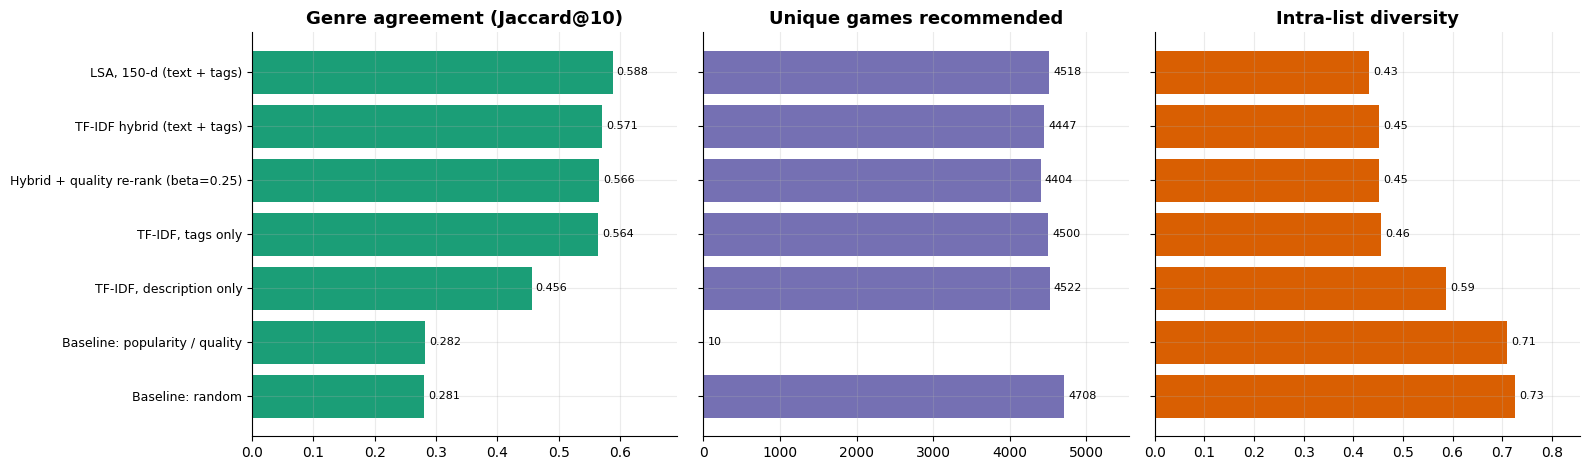

In [34]:
order = results.index[::-1]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, col, title, color, fmt in [
    (axes[0], "Genre Jaccard@10",         "Genre agreement (Jaccard@10)", PALETTE[0], "%.3f"),
    (axes[1], "Unique games recommended", "Unique games recommended",     PALETTE[2], "%d"),
    (axes[2], "Intra-list diversity",     "Intra-list diversity",         PALETTE[1], "%.2f"),
]:
    bars = ax.barh(order, results.loc[order, col], color=color)
    ax.bar_label(bars, fmt=fmt, padding=3, fontsize=8)
    ax.margins(x=0.18)
    ax.set_title(title)
axes[0].tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

**Reading the results.** The standard error on Genre Jaccard@10 is about 0.008, so differences of a few thousandths are noise.

* **Both baselines sit near 0.28.** The popularity baseline gives all 500 queries the same 10 games, which shows why popularity alone is not personalised discovery.
* **Description text alone reaches 0.46**, far above random, even though that model never sees a genre. The NLP pipeline recovers genre structure from prose. It is also the most varied (diversity 0.59), at the cost of relevance.
* **Tags are the stronger single signal (0.56).** Adding text gives 0.57, a difference within noise on this metric. Note that user tags and official genres are closely related, so this yardstick favours tag-based models; the description-only result is the one that is fully independent of it.
* **LSA is the most genre-consistent (0.59)**, about 0.02 above the sparse hybrid, roughly two standard errors. That is suggestive of a modest benefit from the smoothing, not conclusive. Its lists are slightly less genre-diverse (0.43 vs. 0.45).
* **Quality re-ranking at β = 0.25 costs almost no relevance** (0.571 → 0.566, within noise) while raising mean quality from 0.50 to 0.59. It also shifts recommendations towards popular games (mean popularity percentile 0.52 → 0.59) and slightly reduces coverage (4,447 → 4,404 distinct games).
* All content models recommend about 4,400 to 4,500 distinct games across the 5,000 list slots, so none collapses onto a small set of items.

### 8.2 The relevance / reliability trade-off (sweeping β)

How much does mixing in quality cost in genre agreement, and how much reliability does it buy? We re-rank the stored candidate pools at several values of β.

,Genre Jaccard@10,Precision@10,Mean quality,Mean popularity pct.,Unique games recommended
beta,,,,,
0.00,0.571,0.661,0.500,0.521,4447
0.10,0.570,0.663,0.534,0.544,4450
0.25,0.566,0.655,0.592,0.585,4404
0.40,0.564,0.654,0.675,0.649,4246
0.60,0.543,0.626,0.806,0.759,3765
0.80,0.521,0.596,0.874,0.827,3256


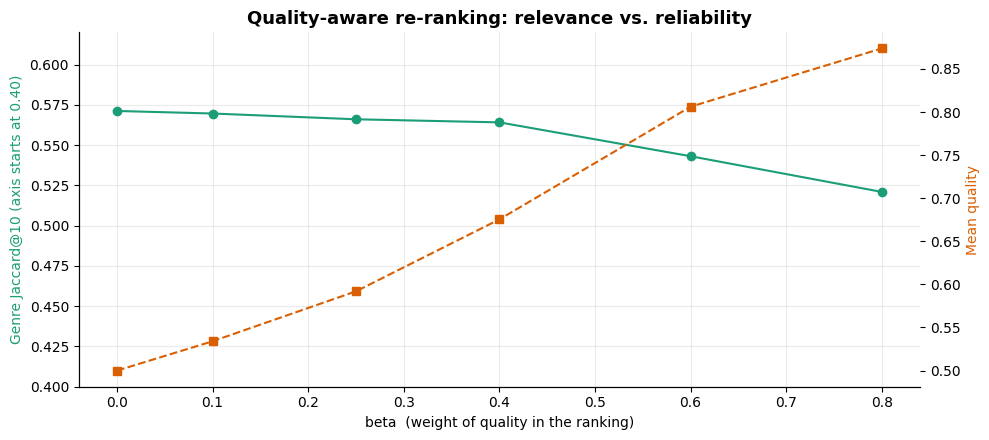

In [35]:
rows = []
for beta in [0.0, 0.1, 0.25, 0.4, 0.6, 0.8]:
    lists = {q: rerank_pool(*pools[q], TOP_N, beta)[0] for q in query_idx}
    rows.append({"beta": beta, **evaluate(lists)})
sweep = pd.DataFrame(rows).set_index("beta")
display(sweep[["Genre Jaccard@10", "Precision@10", "Mean quality", "Mean popularity pct.", "Unique games recommended"]].round(3))

fig, ax1 = plt.subplots()
ax1.plot(sweep.index, sweep["Genre Jaccard@10"], "o-", color=PALETTE[0], label="Genre Jaccard@10 (relevance)")
ax1.set_xlabel("beta  (weight of quality in the ranking)")
ax1.set_ylabel("Genre Jaccard@10 (axis starts at 0.40)", color=PALETTE[0])
ax1.set_ylim(0.40, 0.62)
ax2 = ax1.twinx()
ax2.plot(sweep.index, sweep["Mean quality"], "s--", color=PALETTE[1], label="Mean quality (reliability)")
ax2.set_ylabel("Mean quality", color=PALETTE[1])
ax2.grid(False)
ax1.set_title("Quality-aware re-ranking: relevance vs. reliability")
plt.tight_layout()
plt.show()

**Reading the trade-off.** Up to β ≈ 0.4, genre agreement barely moves (0.571 → 0.564) while mean quality climbs from 0.50 to 0.68. Beyond that the cost grows: at β = 0.8 Jaccard falls to 0.52 and recommendations concentrate on popular games (distinct games recommended drop from 4,447 to 3,256, mean popularity percentile 0.83). The default `BETA = 0.25` sits in the flat part of the curve. The left axis does not start at zero, so the small changes are easier to see.

---
## 9. Visualising the Game Embedding Space

As a final check that the learned representation is sensible, we project the 150-dimensional LSA vectors of a random sample of 3,000 games onto two dimensions with **t-SNE** and colour each game by its main genre. t-SNE preserves local neighbourhoods, so games that our model considers similar should land close together. The model was never given genre labels, so any genre structure comes purely from text and tags.

t-SNE done in 16s


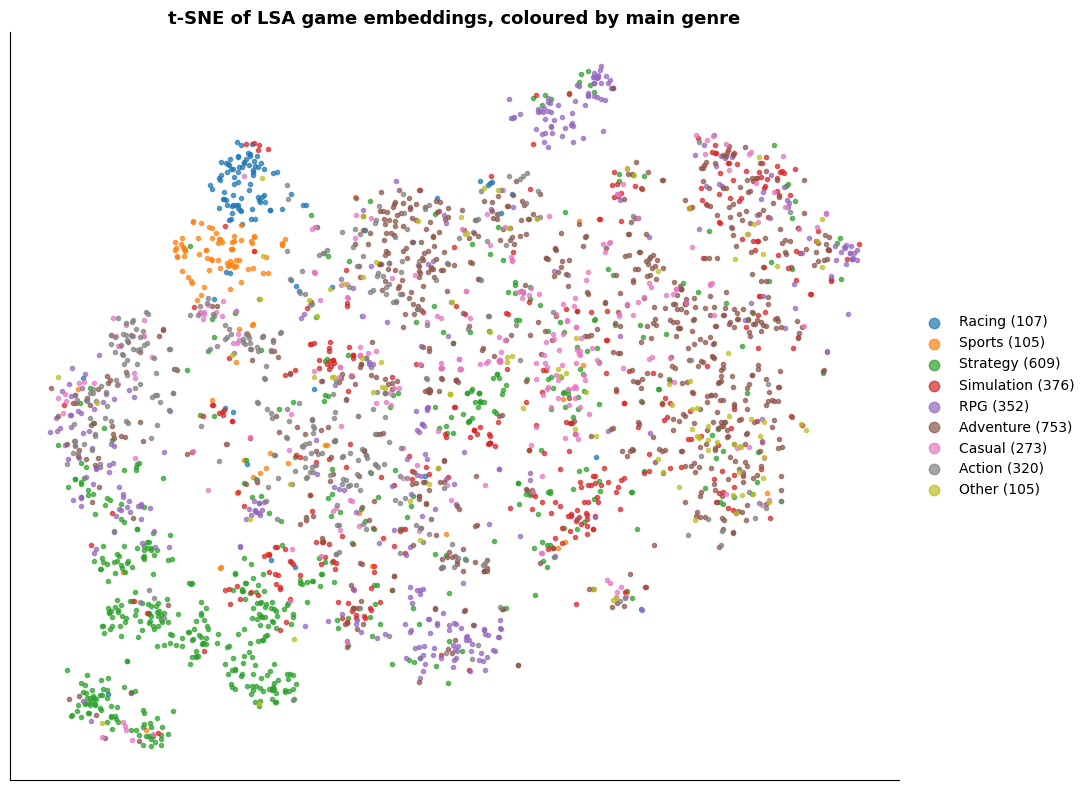

In [36]:
GROUP_PRIORITY = ["Racing", "Sports", "Strategy", "Simulation", "RPG", "Adventure", "Casual", "Action"]


def primary_group(genres):
    for g in GROUP_PRIORITY:
        if g in genres:
            return g
    return "Other"


groups = catalog["genre_list"].map(primary_group).to_numpy()
sample = rng.choice(len(catalog), size=3000, replace=False)

t0 = time.time()
coords = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto",
              random_state=RANDOM_STATE).fit_transform(Z[sample])
print(f"t-SNE done in {time.time() - t0:.0f}s")

colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(11, 8))
for color, g in zip(colors, GROUP_PRIORITY + ["Other"]):
    m = groups[sample] == g
    ax.scatter(coords[m, 0], coords[m, 1], s=9, alpha=0.7, color=color, label=f"{g} ({m.sum()})")
ax.set_title("t-SNE of LSA game embeddings, coloured by main genre")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.legend(markerscale=2.5, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.show()

**Reading the map.** Specific genres form clear regions: Racing and Sports are compact, well-separated clusters, and Strategy and RPG occupy recognisable areas. The broad genres (Adventure, Casual, Action) overlap heavily. Each game is coloured by a single main genre chosen by a fixed priority order, with the broadest genres last, and most games carry several genres. The model never saw genre labels, so this structure comes entirely from descriptions and tags.

---
## 10. Conclusions, Limitations and Future Work

### 10.1 What we built

An end-to-end recommender for the Steam catalogue that works from nothing but the game catalogue itself:

* a **cleaning pipeline** that repairs a malformed header, removes duplicates and builds a quality-filtered catalogue;
* an **NLP pipeline** (HTML/URL stripping, domain-aware stop words, uni/bi-gram TF-IDF) plus a tag representation, fused into one hybrid feature space;
* **five ways to ask for recommendations**: by title, by latent-semantic similarity, with quality-aware re-ranking, from a multi-game taste profile, and by free-text description, with an **explanation** for each suggestion;
* an **offline evaluation** against a held-out signal (official genres), with beyond-accuracy metrics (diversity, coverage, popularity bias), baselines and standard errors.

### 10.2 Key findings

1. **Data preparation mattered.** The raw header was misaligned, duplicates had to be removed, and only 41,513 of 125,846 titles (33%) qualify as reviewed, English-language, non-adult games with one entry per title. Filters also need sanity-checking against well-known titles: a naive "Nudity"-tag filter would remove *The Witcher 3* and *Cyberpunk 2077*, and requiring a description would drop games whose description is empty in this dump (including *The Witcher 3*).
2. **NLP alone carries real signal.** Description-only TF-IDF reaches 0.46 genre agreement versus 0.28 for random, without ever seeing a genre. Tags are stronger (0.56), and LSA on the combined features is the most genre-consistent (0.59), though only modestly ahead of the sparse hybrid.
3. **Pure similarity surfaces obscure titles.** For *Stardew Valley*, the similarity-only list includes a game with just 30 reviews and another rated only 57% positive. Quality-aware re-ranking drops both and promotes well-reviewed alternatives (e.g. *Dinkum*, *Littlewood*) at little measured cost in relevance up to β ≈ 0.4.
4. **The qualitative results are sensible.** *The Witcher 3* yields *Cyberpunk 2077*, the earlier *Witcher* games and *Dragon Age*; a *Stardew Valley* + *Terraria* + *Factorio* taste profile yields survival-crafting games such as *Rust* and *Satisfactory*; and free-text queries return plausible games (a farming query returns *Dinkum* and *Stardew Valley*; a team-shooter query returns *Splitgate*, *Counter-Strike: Source* and *Quake Live*). These are hand-inspected examples, not a quantitative test.

### 10.3 Limitations

* **No user interactions.** Without play or rating histories this is a *content-based* system: it can say which games are alike, but not which games *people like you* enjoyed. It also cannot learn that two dissimilar games are often played by the same people.
* **Lexical features.** TF-IDF matches words, not meaning. LSA softens this, but descriptions are written as marketing copy, and similar games can be described very differently.
* **Proxy evaluation.** Genre agreement measures relatedness, not satisfaction, and user tags correlate with genres, which favours tag-based models. With 500 queries, differences of about 0.01 are within noise. The only real test is online (click-through, play time, wishlists).
* **Recency gap.** Only games with at least `MIN_REVIEWS` reviews are recommended, so recent releases are under-represented (9% of 2025 releases and none of 2026's are in the catalogue). Titles with an empty description rely on their tags alone.
* **Heuristic filters.** The adult-only filter relies on Steam's genres and tags, and a few borderline titles can slip through (one appears in the *Witcher 3* example in section 7.2).
* **Free-text search is not quantitatively evaluated.** Its defaults (LSA space, `beta=0.5`) were chosen by inspecting a handful of queries, and the offline evaluation in section 8 covers title-to-title recommendation only.
* **Popularity bias.** Quality-aware re-ranking deliberately favours well-reviewed games, which helps reliability but disadvantages new releases and hidden gems. Games with fewer than `MIN_REVIEWS` reviews are never recommended.
* **English only, one snapshot.** Non-English descriptions are filtered out, and the catalogue reflects a single point in time.
* **Tag quality.** User-voted tags are noisy and can be gamed.

### 10.4 Future work

1. **Collaborative filtering.** Combine this catalogue with a user–item interaction dataset (for example public Steam review or playtime data). Implicit-feedback matrix factorisation (ALS or BPR) would then supply the "people like you" signal, with the content model here handling **cold-start** for new games. A sketch, assuming `interactions` is a sparse users × games matrix:

   ```python
   # pip install implicit
   from implicit.als import AlternatingLeastSquares
   als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=20)
   als.fit(interactions)                                   # users x games, implicit confidence
   ids, scores = als.recommend(user_id, interactions[user_id], N=10)
   ```
   A simple hybrid then blends `als` scores with the content-based and quality scores used here.
2. **Better text understanding.** Enable the transformer embeddings (section 7.8), or fine-tune a sentence model on tag co-occurrence so that "same tags" becomes the training signal.
3. **Diversity-aware ranking.** Apply Maximal Marginal Relevance (MMR) so a list of 10 is not ten near-identical clones.
4. **Richer signals.** Add price, release recency, playtime and developer or publisher affinity as ranking features, and learn the blend weights with a learning-to-rank model.
5. **Serving at scale.** Precompute embeddings and use an approximate nearest-neighbour index (FAISS or Annoy) for millisecond lookups.
6. **Online evaluation.** A/B test against the current Steam recommendations or a popularity baseline, tracking click-through, wishlist adds and playtime.

---
*End of notebook.*